<a href="https://colab.research.google.com/github/dhanush-sai123/ML-labs/blob/main/exp6postlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Explained Variance:
[0.31082291 0.27272501]
Total Variance Explained: 0.5835479180608656


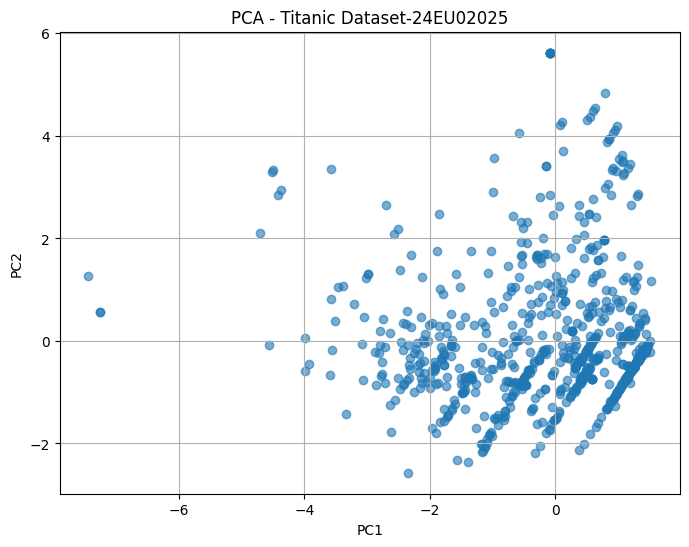

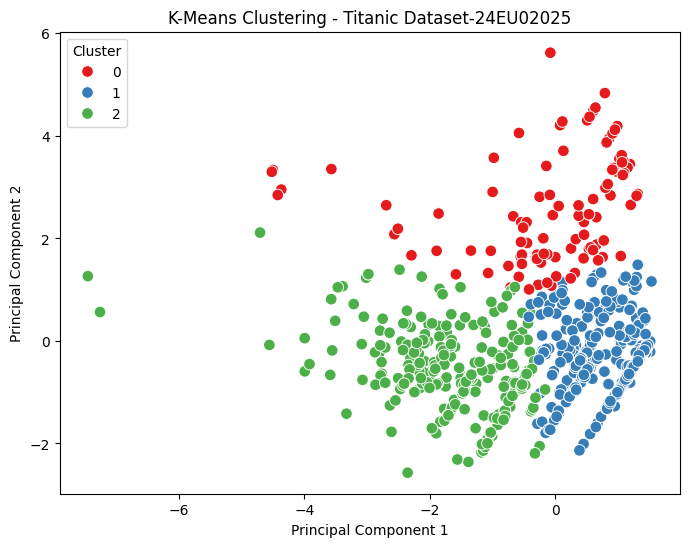

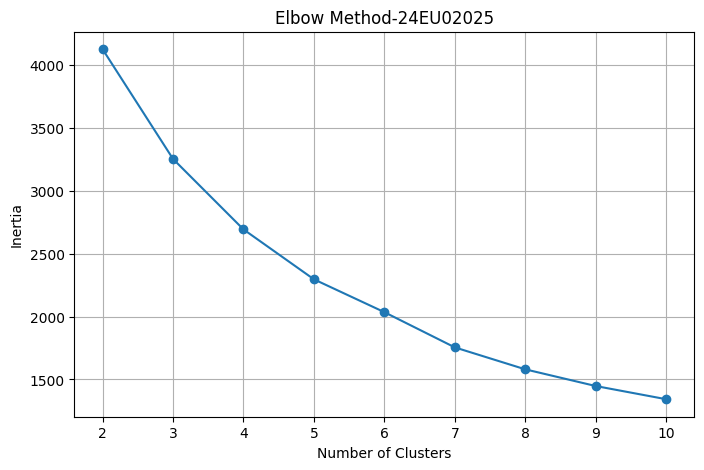


Silhouette Scores:
K=2: 0.308
K=3: 0.345
K=4: 0.354
K=5: 0.372

Cluster Summary:
         survived    pclass        age     sibsp     parch       fare
Cluster                                                              
0        0.478261  2.565217  15.528261  2.243478  1.930435  45.958152
1        0.199609  2.812133  28.370685  0.223092  0.091977  11.986153
2        0.698113  1.226415  37.275472  0.354717  0.267925  65.222028

Number of passengers in each cluster:
Cluster
0    115
1    511
2    265
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --------------------------------
# 1. Load Titanic built-in dataset
# --------------------------------
titanic = sns.load_dataset("titanic")

print("Dataset Shape:", titanic.shape)
print(titanic.head())

# --------------------------------
# 2. Select features
# --------------------------------
features = [
    'survived',
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

df = titanic[features].copy()

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())

# --------------------------------
# 3. Standardization
# --------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# --------------------------------
# 4. PCA
# --------------------------------
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

print("\nExplained Variance:")
print(pca.explained_variance_ratio_)

print(
    "Total Variance Explained:",
    pca.explained_variance_ratio_.sum()
)

# --------------------------------
# 5. PCA Visualization
# --------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Titanic Dataset-24EU02025")
plt.grid()

plt.show()

# --------------------------------
# 6. K-Means Clustering
# --------------------------------
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
pca_df['Cluster'] = clusters

# --------------------------------
# 7. Cluster Visualization
# --------------------------------
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=70
)

plt.title("K-Means Clustering - Titanic Dataset-24EU02025")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# --------------------------------
# 8. Elbow Method
# --------------------------------
inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method-24EU02025")
plt.grid()

plt.show()

# --------------------------------
# 9. Silhouette Score
# --------------------------------
print("\nSilhouette Scores:")

for k in range(2, 6):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}: {score:.3f}")

# --------------------------------
# 10. Cluster Summary
# --------------------------------
print("\nCluster Summary:")
print(df.groupby('Cluster').mean())

print("\nNumber of passengers in each cluster:")
print(df['Cluster'].value_counts().sort_index())